<a href="https://colab.research.google.com/github/kjahan/self_taught_reasoner/blob/main/notebooks/verifiers/rl_lm_image_planner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stable Diffusion v1.5 vs Midjourney v4 Diffusion


https://huggingface.co/prompthero/midjourney-v4-diffusion

https://github.com/amrrs/midjourney4-stable-diffusion/blob/main/MidJourney_Style_Images_from_Fine_tuned_Stable_Diffusion.ipynb

https://www.youtube.com/watch?v=nYi1dE3qK6U

In [1]:
!pip install transformers diffusers accelerate -q

In [2]:
from diffusers import StableDiffusionPipeline
import torch

import time

In [3]:
model_path = 'prompthero/midjourney-v4-diffusion'

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["id2label"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["bos_token_id"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["eos_token_id"]` will be overriden.


## Turn off NSFW

https://github.com/CompVis/stable-diffusion/issues/239

https://stackoverflow.com/questions/75641074/i-run-stable-diffusion-its-wrong-runtimeerror-layernormkernelimpl-not-implem

In [45]:
# pipe = StableDiffusionPipeline.from_pretrained(model_path, torch_dtype=torch.float16)

pipe = StableDiffusionPipeline.from_pretrained(
    model_path,
    torch_dtype=torch.float32,
    safety_checker = None,
    requires_safety_checker = False
)

if torch.cuda.is_available():
  pipe = pipe.to("cuda")

device = "GPU 🔥" if torch.cuda.is_available() else "CPU 🥶"

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

In [4]:
!nvidia-smi

Tue Nov 28 04:55:34 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.105.17   Driver Version: 525.105.17   CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   59C    P8    10W /  70W |      0MiB / 15360MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [5]:
device

'GPU 🔥'

## Human Prompt

In [55]:
base_prompt = "a beautiful anime cyborg girl with yellow eyes wearing a cat hoodie, pretty detailed eyes, full body. City background. posture by j scott campbell, perfect shading, soft studio lighting, ultra-realistic, photorealistic, octane render, cinematic lighting, hdr, in-frame, 4k, 8k, edge lighting"  #@param {type:"string"}
prompt = "mdjrny-v4 style " + base_prompt

prompt

'mdjrny-v4 style a beautiful anime cyborg girl with yellow eyes wearing a cat hoodie, pretty detailed eyes, full body. City background. posture by j scott campbell, perfect shading, soft studio lighting, ultra-realistic, photorealistic, octane render, cinematic lighting, hdr, in-frame, 4k, 8k, edge lighting'

  0%|          | 0/50 [00:00<?, ?it/s]

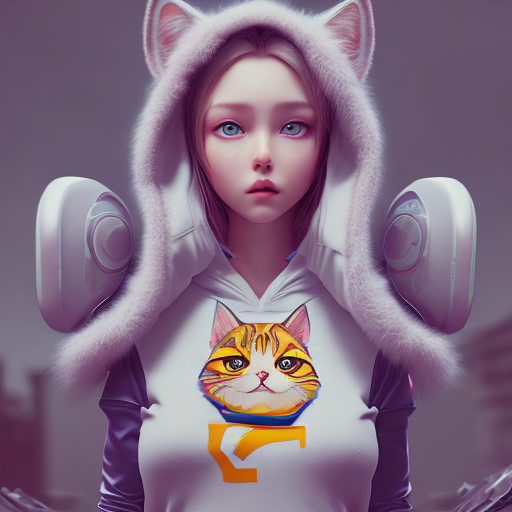

In [58]:
result = pipe(
      prompt,
      width = 512,
      height = 512)

image = result.images[0]

image.save("sd_img_{}.png".format(int(time.time())))

image

## GPT prompt

IO Prompt for ChatGPT

`You are a prompt optimizer for a stable diffusion model where we give a prompt and then the model generates an image. Your goal is to modify the prompt so that it adds some feature to the base prompt. I'll give you the base prompt where you should do minimum changes to in order to achive the goal. Here is the prompt:`

`"a beautiful anime cyborg girl with yellow eyes wearing a cat hoodie, pretty detailed eyes, full body. City background. posture by j scott campbell, perfect shading, soft studio lighting, ultra-realistic, photorealistic, octane render, cinematic lighting, hdr, in-frame, 4k, 8k, edge lighting"`

`Now make the minimum modification to the above prompt so that the produced image is waering a sunglass.`

ChatGPT output as Nov 27th:

`"An ultra-realistic anime cyborg girl with yellow eyes wearing a cat hoodie and stylish sunglasses, pretty detailed eyes, full body. City background. Posture by J Scott Campbell, perfect shading, soft studio lighting, ultra-realistic, photorealistic, Octane render, cinematic lighting, HDR, in-frame, 4k, 8k, edge lighting."`

In [8]:
gpt_base_prompt = "An ultra-realistic anime cyborg girl with yellow eyes wearing a cat hoodie and stylish sunglasses, pretty detailed eyes, full body. City background. Posture by J Scott Campbell, perfect shading, soft studio lighting, ultra-realistic, photorealistic, Octane render, cinematic lighting, HDR, in-frame, 4k, 8k, edge lighting."

gpt_prompt = "mdjrny-v4 style " + gpt_base_prompt

gpt_prompt

'mdjrny-v4 style An ultra-realistic anime cyborg girl with yellow eyes wearing a cat hoodie and stylish sunglasses, pretty detailed eyes, full body. City background. Posture by J Scott Campbell, perfect shading, soft studio lighting, ultra-realistic, photorealistic, Octane render, cinematic lighting, HDR, in-frame, 4k, 8k, edge lighting.'

Token indices sequence length is longer than the specified maximum sequence length for this model (79 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['lighting.']


  0%|          | 0/50 [00:00<?, ?it/s]

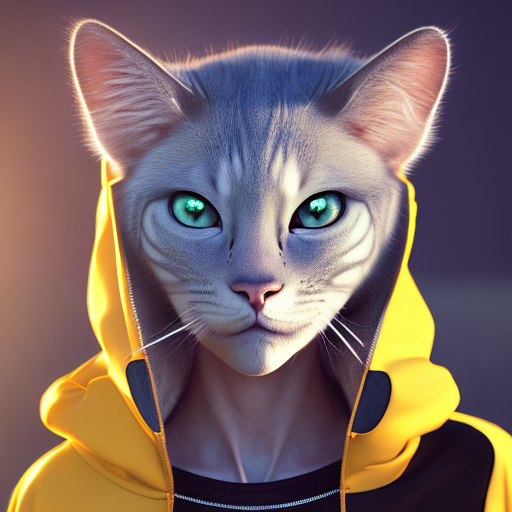

In [9]:
result = pipe(
      gpt_prompt,
      width = 512,
      height = 512)

image = result.images[0]

image.save("sd_img_{}.png".format(int(time.time())))

image

## COT Try 1

Prompt:

`You are an advanced prompt optimizer for a stable diffusion model to generate a very creative and futuristic image. I'll give you the base prompt which you should modify in order to achive the goal. Here is the base prompt:`

`"a beautiful anime cyborg girl with yellow eyes wearing a cat hoodie, pretty detailed eyes, full body. City background. posture by j scott campbell, perfect shading, soft studio lighting, ultra-realistic, photorealistic, octane render, cinematic lighting, hdr, in-frame, 4k, 8k, edge lighting"`

`Make the modification to the base prompt so that the produced image is wearing a sunglass.`

`Make a plan then write. Your output should be of the following format:`

`Plan:
Your plan here.`

`Prompt:
Your prompt here.`


ChatGPT output as Nov 27th:

`Plan:`

`1. Introduce the concept of a futuristic and cyberpunk environment to enhance the creativity.`

`2. Specify the sunglasses as a futuristic and high-tech accessory to align with the theme.`

`3. Emphasize a dynamic and visually striking pose for the anime cyborg girl to add an element of creativity.`

`Prompt:`

`"A captivating anime cyborg girl with striking yellow eyes donned in a cat hoodie and cutting-edge, futuristic sunglasses. Detailed, expressive eyes, portraying a vibrant personality, in a dynamic full-body pose against a cyberpunk cityscape. Posture inspired by J Scott Campbell, featuring impeccable shading, soft studio lighting for an ultra-realistic and photorealistic rendering using Octane. Employ cinematic lighting techniques, HDR effects, and edge lighting to bring out the essence of the futuristic scene. Ensure the image is in-frame, available in 4k and 8k resolution, capturing the perfect blend of cybernetic beauty and high-tech aesthetics."`

In [10]:
gpt_base_prompt = "A captivating anime cyborg girl with striking yellow eyes donned in a cat hoodie and cutting-edge, futuristic sunglasses. Detailed, expressive eyes, portraying a vibrant personality, in a dynamic full-body pose against a cyberpunk cityscape. Posture inspired by J Scott Campbell, featuring impeccable shading, soft studio lighting for an ultra-realistic and photorealistic rendering using Octane. Employ cinematic lighting techniques, HDR effects, and edge lighting to bring out the essence of the futuristic scene. Ensure the image is in-frame, available in 4k and 8k resolution, capturing the perfect blend of cybernetic beauty and high-tech aesthetics."

gpt_prompt = "mdjrny-v4 style " + gpt_base_prompt

gpt_prompt

'mdjrny-v4 style A captivating anime cyborg girl with striking yellow eyes donned in a cat hoodie and cutting-edge, futuristic sunglasses. Detailed, expressive eyes, portraying a vibrant personality, in a dynamic full-body pose against a cyberpunk cityscape. Posture inspired by J Scott Campbell, featuring impeccable shading, soft studio lighting for an ultra-realistic and photorealistic rendering using Octane. Employ cinematic lighting techniques, HDR effects, and edge lighting to bring out the essence of the futuristic scene. Ensure the image is in-frame, available in 4k and 8k resolution, capturing the perfect blend of cybernetic beauty and high-tech aesthetics.'

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['realistic rendering using octane. employ cinematic lighting techniques, hdr effects, and edge lighting to bring out the essence of the futuristic scene. ensure the image is in - frame, available in 4 k and 8 k resolution, capturing the perfect blend of cybernetic beauty and high - tech aesthetics.']


  0%|          | 0/50 [00:00<?, ?it/s]

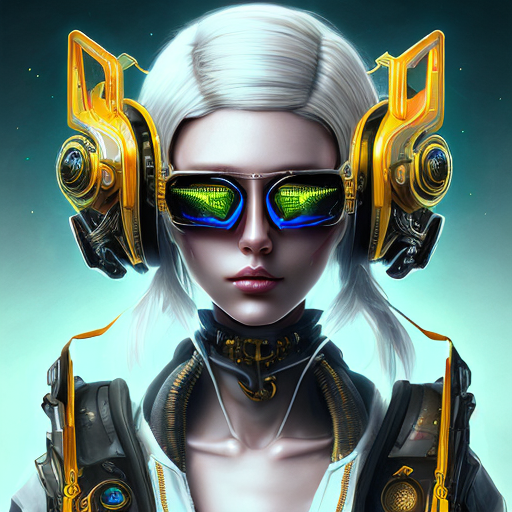

In [11]:
result = pipe(
      gpt_prompt,
      width = 512,
      height = 512)

image = result.images[0]

image.save("sd_img_{}.png".format(int(time.time())))

image

## COT Try 2

`Plan:`

`1. Retain the key elements of the base prompt describing a beautiful anime cyborg girl with yellow eyes, wearing a cat hoodie, with detailed eyes, and a full body.`

`2. Add a mention of futuristic and creative elements to enhance the overall theme.`

`3. Specify the addition of stylish sunglasses to the cyborg girl's attire.`

`Prompt:
"A futuristic and creatively designed anime cyborg girl with striking yellow eyes, adorned in a fashionable cat hoodie and stylish sunglasses. The detailed eyes and full body are accentuated with a city background, capturing a dynamic posture inspired by J Scott Campbell. Achieve perfection through meticulous shading and embrace ultra-realistic qualities with photorealistic details. Employ the advanced capabilities of Octane render for cinematic lighting effects and utilize HDR for an immersive experience. Ensure the composition is in-frame, available in 4k and 8k resolution, with the enhancement of edge lighting to evoke a futuristic ambiance."`

In [12]:
gpt_base_prompt = "A futuristic and creatively designed anime cyborg girl with striking yellow eyes, adorned in a fashionable cat hoodie and stylish sunglasses. The detailed eyes and full body are accentuated with a city background, capturing a dynamic posture inspired by J Scott Campbell. Achieve perfection through meticulous shading and embrace ultra-realistic qualities with photorealistic details. Employ the advanced capabilities of Octane render for cinematic lighting effects and utilize HDR for an immersive experience. Ensure the composition is in-frame, available in 4k and 8k resolution, with the enhancement of edge lighting to evoke a futuristic ambiance."

gpt_prompt = "mdjrny-v4 style " + gpt_base_prompt

gpt_prompt

'mdjrny-v4 style A futuristic and creatively designed anime cyborg girl with striking yellow eyes, adorned in a fashionable cat hoodie and stylish sunglasses. The detailed eyes and full body are accentuated with a city background, capturing a dynamic posture inspired by J Scott Campbell. Achieve perfection through meticulous shading and embrace ultra-realistic qualities with photorealistic details. Employ the advanced capabilities of Octane render for cinematic lighting effects and utilize HDR for an immersive experience. Ensure the composition is in-frame, available in 4k and 8k resolution, with the enhancement of edge lighting to evoke a futuristic ambiance.'

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['employ the advanced capabilities of octane render for cinematic lighting effects and utilize hdr for an immersive experience. ensure the composition is in - frame, available in 4 k and 8 k resolution, with the enhancement of edge lighting to evoke a futuristic ambiance.']


  0%|          | 0/50 [00:00<?, ?it/s]

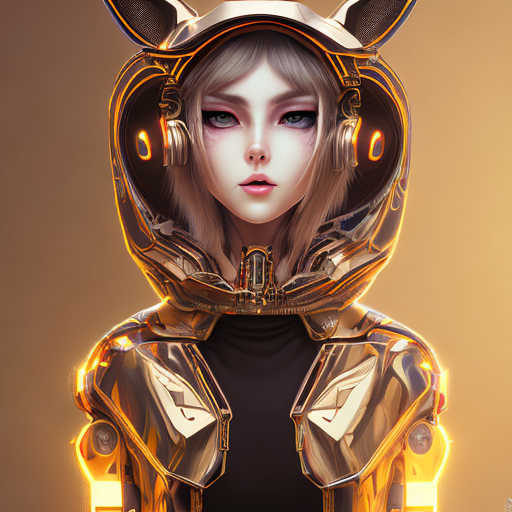

In [13]:
result = pipe(
      gpt_prompt,
      width = 512,
      height = 512)

image = result.images[0]

image.save("sd_img_{}.png".format(int(time.time())))

image

## COT Try 3

**Plan:**

1. Retain the core elements of the base prompt, focusing on the beautiful anime cyborg girl with yellow eyes, cat hoodie, and the specified details.
2. Introduce the addition of sunglasses to the character's attire for a creative and futuristic touch.
3. Maintain the city background, J Scott Campbell posture, and the specified rendering and lighting details to ensure consistency with the base prompt.

**Prompt:**

"A stunning anime cyborg girl with striking yellow eyes donning a cat hoodie, detailed eyes, and a full body. Placed against a futuristic city backdrop, adopting a dynamic posture inspired by J Scott Campbell. Achieve perfection through meticulous shading, employing soft studio lighting for ultra-realistic and photorealistic effects. Utilize Octane render with cinematic lighting, HDR, in-frame composition, and options for 4k or 8k resolution. Elevate the aesthetic with the addition of stylish sunglasses, seamlessly integrated into the futuristic ensemble. Implement edge lighting to enhance the overall visual impact."

In [14]:
gpt_base_prompt = "A stunning anime cyborg girl with striking yellow eyes donning a cat hoodie, detailed eyes, and a full body. Placed against a futuristic city backdrop, adopting a dynamic posture inspired by J Scott Campbell. Achieve perfection through meticulous shading, employing soft studio lighting for ultra-realistic and photorealistic effects. Utilize Octane render with cinematic lighting, HDR, in-frame composition, and options for 4k or 8k resolution. Elevate the aesthetic with the addition of stylish sunglasses, seamlessly integrated into the futuristic ensemble. Implement edge lighting to enhance the overall visual impact."

gpt_prompt = "mdjrny-v4 style " + gpt_base_prompt

gpt_prompt

'mdjrny-v4 style A stunning anime cyborg girl with striking yellow eyes donning a cat hoodie, detailed eyes, and a full body. Placed against a futuristic city backdrop, adopting a dynamic posture inspired by J Scott Campbell. Achieve perfection through meticulous shading, employing soft studio lighting for ultra-realistic and photorealistic effects. Utilize Octane render with cinematic lighting, HDR, in-frame composition, and options for 4k or 8k resolution. Elevate the aesthetic with the addition of stylish sunglasses, seamlessly integrated into the futuristic ensemble. Implement edge lighting to enhance the overall visual impact.'

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['lighting, hdr, in - frame composition, and options for 4 k or 8 k resolution. elevate the aesthetic with the addition of stylish sunglasses, seamlessly integrated into the futuristic ensemble. implement edge lighting to enhance the overall visual impact.']


  0%|          | 0/50 [00:00<?, ?it/s]

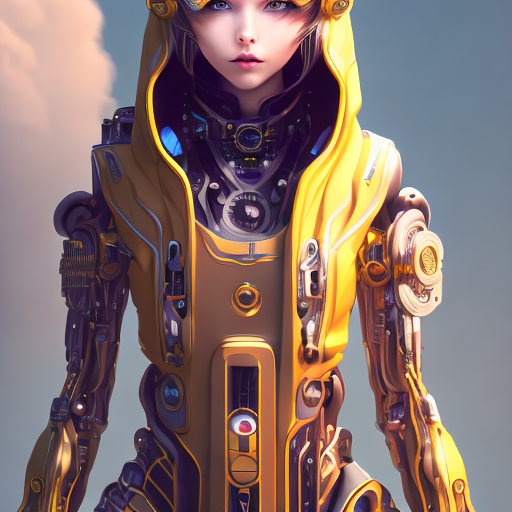

In [15]:
result = pipe(
      gpt_prompt,
      width = 512,
      height = 512)

image = result.images[0]

image.save("sd_img_{}.png".format(int(time.time())))

image

## COT Try 4

Plan:
To add sunglasses to the anime cyborg girl in the generated image, I'll explicitly include this detail in the prompt. I'll make sure to maintain the overall structure and creative elements of the base prompt while introducing the sunglasses specification.

Prompt:
"A futuristic anime cyborg girl with striking yellow eyes is donned in a stylish cat hoodie and sleek sunglasses, boasting intricate eye details and a captivating full-body composition. The backdrop features a bustling cityscape. The posture is inspired by J Scott Campbell, ensuring dynamic and visually engaging positioning. The shading is meticulously executed, complemented by soft studio lighting, resulting in an ultra-realistic and photorealistic appearance. The rendering utilizes Octane render, incorporating cinematic lighting and HDR effects for an in-frame masterpiece available in 4k and 8k resolutions. The overall ambiance is enhanced by edge lighting, providing a futuristic and creative touch."

In [16]:
gpt_base_prompt = "A futuristic anime cyborg girl with striking yellow eyes is donned in a stylish cat hoodie and sleek sunglasses, boasting intricate eye details and a captivating full-body composition. The backdrop features a bustling cityscape. The posture is inspired by J Scott Campbell, ensuring dynamic and visually engaging positioning. The shading is meticulously executed, complemented by soft studio lighting, resulting in an ultra-realistic and photorealistic appearance. The rendering utilizes Octane render, incorporating cinematic lighting and HDR effects for an in-frame masterpiece available in 4k and 8k resolutions. The overall ambiance is enhanced by edge lighting, providing a futuristic and creative touch."

gpt_prompt = "mdjrny-v4 style " + gpt_base_prompt

gpt_prompt

'mdjrny-v4 style A futuristic anime cyborg girl with striking yellow eyes is donned in a stylish cat hoodie and sleek sunglasses, boasting intricate eye details and a captivating full-body composition. The backdrop features a bustling cityscape. The posture is inspired by J Scott Campbell, ensuring dynamic and visually engaging positioning. The shading is meticulously executed, complemented by soft studio lighting, resulting in an ultra-realistic and photorealistic appearance. The rendering utilizes Octane render, incorporating cinematic lighting and HDR effects for an in-frame masterpiece available in 4k and 8k resolutions. The overall ambiance is enhanced by edge lighting, providing a futuristic and creative touch.'

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['mented by soft studio lighting, resulting in an ultra - realistic and photorealistic appearance. the rendering utilizes octane render, incorporating cinematic lighting and hdr effects for an in - frame masterpiece available in 4 k and 8 k resolutions. the overall ambiance is enhanced by edge lighting, providing a futuristic and creative touch.']


  0%|          | 0/50 [00:00<?, ?it/s]

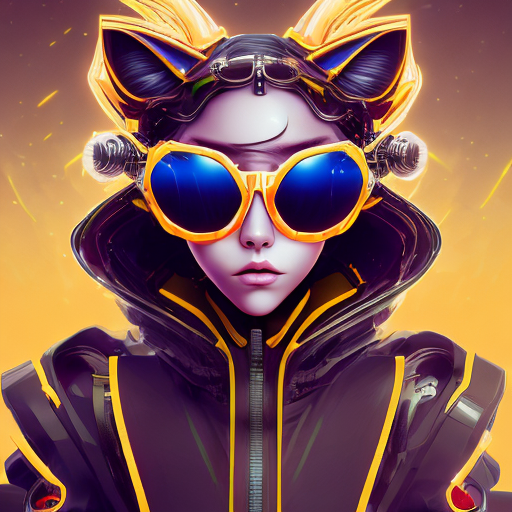

In [17]:
result = pipe(
      gpt_prompt,
      width = 512,
      height = 512)

image = result.images[0]

image.save("sd_img_{}.png".format(int(time.time())))

image

## COT 5

**Plan:**
1. Introduce the element of sunglasses to the character's appearance.
2. Ensure that the sunglasses are seamlessly integrated into the existing description.
3. Maintain the futuristic and creative aspects in the prompt to generate a visually captivating image.

**Prompt:**
"A beautiful anime cyborg girl with yellow eyes and futuristic sunglasses, adorned in a stylish cat hoodie, featuring intricate eye details and a full-body pose. Placed against a dynamic city background, adopting the signature posture by J Scott Campbell, the scene is illuminated with perfect shading, soft studio lighting, and cinematic effects. Rendered with ultra-realism using Octane render, the image showcases photorealistic details enhanced by HDR, all presented in stunning 4k and 8k resolution with mesmerizing edge lighting."

In [18]:
gpt_prompt = "A beautiful anime cyborg girl with yellow eyes and futuristic sunglasses, adorned in a stylish cat hoodie, featuring intricate eye details and a full-body pose. Placed against a dynamic city background, adopting the signature posture by J Scott Campbell, the scene is illuminated with perfect shading, soft studio lighting, and cinematic effects. Rendered with ultra-realism using Octane render, the image showcases photorealistic details enhanced by HDR, all presented in stunning 4k and 8k resolution with mesmerizing edge lighting."

gpt_prompt = "mdjrny-v4 style " + gpt_prompt

gpt_prompt

'mdjrny-v4 style A beautiful anime cyborg girl with yellow eyes and futuristic sunglasses, adorned in a stylish cat hoodie, featuring intricate eye details and a full-body pose. Placed against a dynamic city background, adopting the signature posture by J Scott Campbell, the scene is illuminated with perfect shading, soft studio lighting, and cinematic effects. Rendered with ultra-realism using Octane render, the image showcases photorealistic details enhanced by HDR, all presented in stunning 4k and 8k resolution with mesmerizing edge lighting.'

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['using octane render, the image showcases photorealistic details enhanced by hdr, all presented in stunning 4 k and 8 k resolution with mesmerizing edge lighting.']


  0%|          | 0/50 [00:00<?, ?it/s]

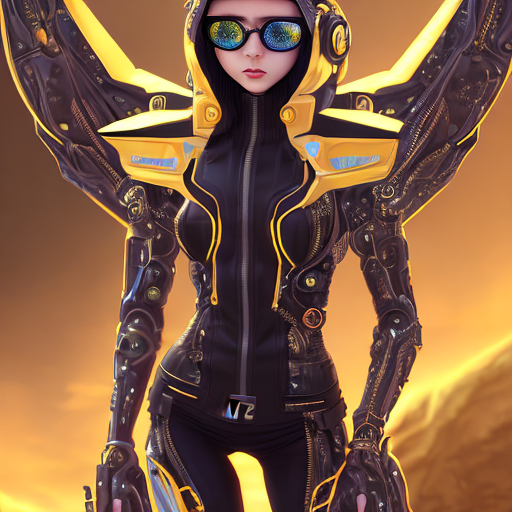

In [19]:
result = pipe(
      gpt_prompt,
      width = 512,
      height = 512)

image = result.images[0]

image.save("sd_img_{}.png".format(int(time.time())))

image

## Samurai IO prompt

mdjrny-v4 style Full body view of a Samurai warrior in the year 2432, 4k upscale, with London background, raining


  0%|          | 0/50 [00:00<?, ?it/s]

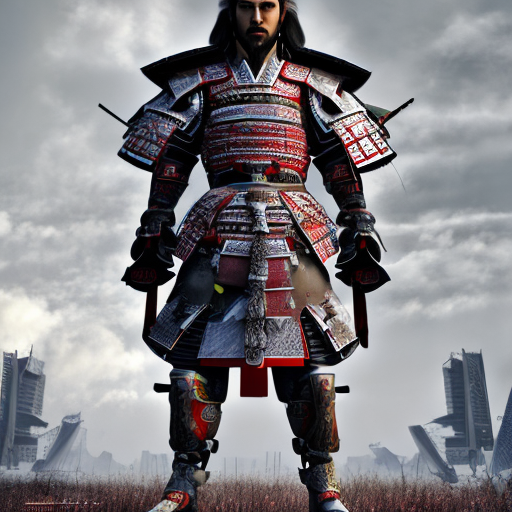

In [20]:
base_prompt = "Full body view of a Samurai warrior in the year 2432, 4k upscale, with London background, raining"

prompt = "mdjrny-v4 style " + base_prompt

print(prompt)
result = pipe(
      prompt,
      width = 512,
      height = 512)
image = result.images[0]

image.save("sd_img_{}.png".format(int(time.time())))

image

## COT Try 1

You are an advanced prompt optimizer for a stable diffusion model to generate a very creative and futuristic image. I'll give you the base prompt which you should modify in order to achive the goal. Here is the base prompt:

"Full body view of a Samurai warrior in the year 2432, 4k upscale, with London background, raining"

Make the modification to the base prompt so that the produced image is wearing a sunglass.

Make a plan then write. Your output should be of the following format:

Plan:
Your plan here.

Prompt:
Your prompt here.


Output

**Plan:**
1. Integrate sunglasses into the futuristic Samurai warrior's attire.
2. Maintain the setting details, including the year 2432, London background, and raining conditions.
3. Enhance the creative and futuristic elements to ensure a visually captivating image.

**Prompt:**
"Full body view of a Samurai warrior in the year 2432, adorned with futuristic sunglasses, presented in a stunning 4k upscale. The warrior stands against the backdrop of a futuristic London, the rain adding an element of dynamism to the scene. The ensemble seamlessly blends traditional Samurai armor with advanced, high-tech details, creating a visually striking and imaginative representation of a warrior in the future metropolis."

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['creating a visually striking and imaginative representation of a warrior in the future metropolis.']


mdjrny-v4 style Full body view of a Samurai warrior in the year 2432, adorned with futuristic sunglasses, presented in a stunning 4k upscale. The warrior stands against the backdrop of a futuristic London, the rain adding an element of dynamism to the scene. The ensemble seamlessly blends traditional Samurai armor with advanced, high-tech details, creating a visually striking and imaginative representation of a warrior in the future metropolis.


  0%|          | 0/50 [00:00<?, ?it/s]

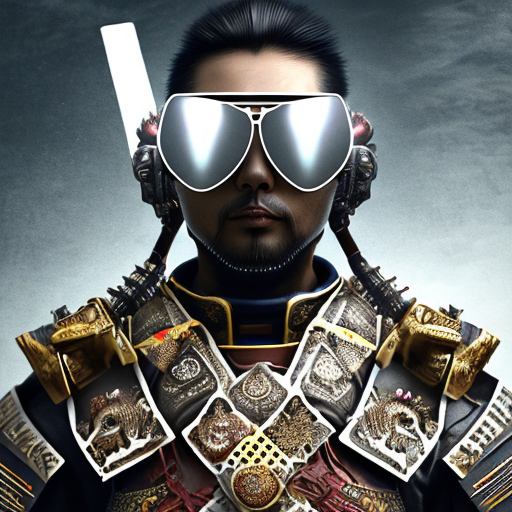

In [21]:
base_prompt = "Full body view of a Samurai warrior in the year 2432, adorned with futuristic sunglasses, presented in a stunning 4k upscale. The warrior stands against the backdrop of a futuristic London, the rain adding an element of dynamism to the scene. The ensemble seamlessly blends traditional Samurai armor with advanced, high-tech details, creating a visually striking and imaginative representation of a warrior in the future metropolis."
prompt = "mdjrny-v4 style " + base_prompt

print(prompt)
result = pipe(
      prompt,
      width = 512,
      height = 512)
image = result.images[0]

image.save("sd_img_{}.png".format(int(time.time())))

image


## COT 2 - 77 limit tokens

You are an advanced prompt optimizer for a stable diffusion model to generate a very creative and futuristic image. I'll give you the base prompt which you should modify in order to achive the goal. Here is the base prompt:

"Full body view of a Samurai warrior in the year 2432, 4k upscale, with London background, raining"

Make the modification to the base prompt so that the produced image is wearing a sunglass. Your prompt must be less than 77 tokens.

Make a plan then write. Your output should be of the following format:

Plan:
Your plan here.

Prompt:
Your prompt here.


**Plan:**
1. Retain the futuristic and creative elements.
2. Add the detail of the Samurai warrior wearing sunglasses.
3. Ensure the prompt remains concise and under 77 tokens.

**Prompt:**
"Full body view of a Samurai warrior in the year 2432, 4k upscale, wearing sleek sunglasses, with a futuristic London background in the rain."


mdjrny-v4 style Full body view of a Samurai warrior in the year 2432, 4k upscale, wearing sleek sunglasses, with a futuristic London background in the rain.


  0%|          | 0/50 [00:00<?, ?it/s]

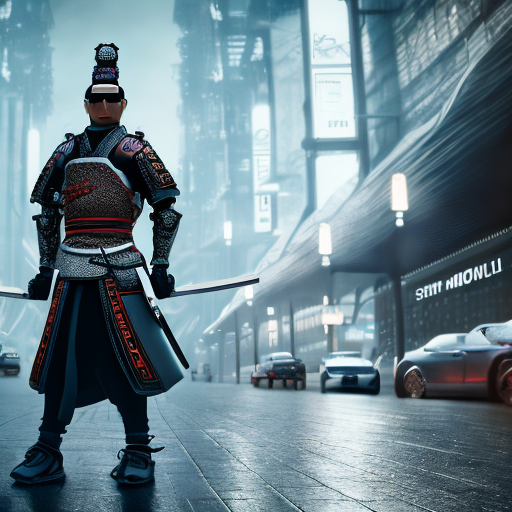

In [22]:
base_prompt = "Full body view of a Samurai warrior in the year 2432, 4k upscale, wearing sleek sunglasses, with a futuristic London background in the rain."


prompt = "mdjrny-v4 style " + base_prompt

print(prompt)
result = pipe(
      prompt,
      width = 512,
      height = 512)
image = result.images[0]

image.save("sd_img_{}.png".format(int(time.time())))

image

## COT 3

**Plan:**
1. Retain the futuristic and creative elements of the prompt.
2. Introduce the detail of sunglasses seamlessly to the Samurai warrior.
3. Ensure the modification keeps the prompt concise, staying within the token limit.

**Prompt:**
"Full-body view of a futuristic Samurai in 2432, wearing sunglasses, 4k upscale, London background, in the rain."

mdjrny-v4 style Full-body view of a futuristic Samurai in 2432, wearing sunglasses, clear fingers, 4k upscale, London background, in the rain.


  0%|          | 0/50 [00:00<?, ?it/s]

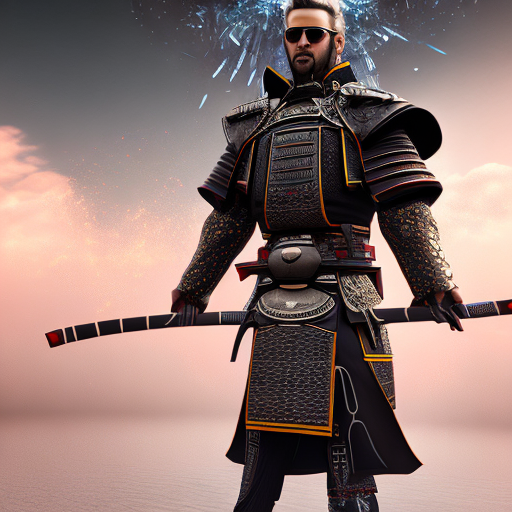

In [23]:
base_prompt = "Full-body view of a futuristic Samurai in 2432, wearing sunglasses, clear fingers, 4k upscale, London background, in the rain."

prompt = "mdjrny-v4 style " + base_prompt

print(prompt)
result = pipe(
      prompt,
      width = 512,
      height = 512)
image = result.images[0]

image.save("sd_img_{}.png".format(int(time.time())))

image

## Negative prompting

https://pixai.art/artwork/1585394153854501496

https://betterwaifu.com/novelai-sex-prompts/

In [24]:
def generate_image_with_neg(pos_prompt, neg_prompt=""):
  prompt = "mdjrny-v4 style " + pos_prompt

  print(prompt)
  if neg_prompt:
    result = pipe(
          prompt=pos_prompt,
          negative_prompt=neg_prompt,
          width = 512,
          height = 512)
  else:
    result = pipe(
          prompt=pos_prompt,
          width = 512,
          height = 512)
  image = result.images[0]

  image.save("sd_img_{}.png".format(int(time.time())))

  return image

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['{ palette, hair that gradually becomes one with the background }}}}} dynamic angle']


mdjrny-v4 style blush,long hair,yellow eyes{{{{{{ond eyes}}}}}}large breasts{{dark skin}}side from,
wide view,two reg,cowboy shot,from above,full body,whole body,Please draw a picture in the genre tha
is best at, change seasons, wind autumn leaves,Beautiful  mountain{{{{{palette,Hair that gradually becomes one with the background}}}}}dynamic angle



  0%|          | 0/50 [00:00<?, ?it/s]

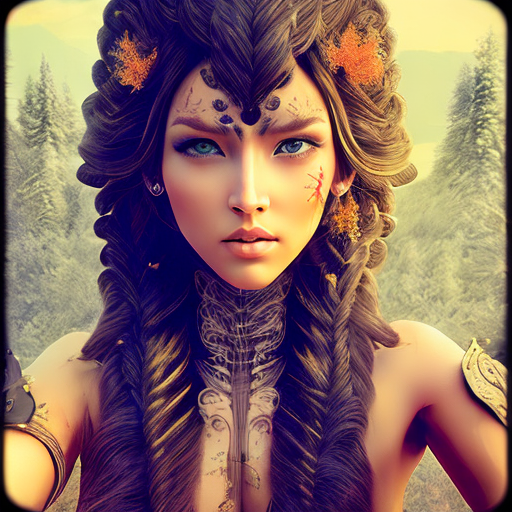

In [25]:
prompt = """blush,long hair,yellow eyes{{{{{{ond eyes}}}}}}large breasts{{dark skin}}side from,
wide view,two reg,cowboy shot,from above,full body,whole body,Please draw a picture in the genre tha
is best at, change seasons, wind autumn leaves,Beautiful  mountain{{{{{palette,Hair that gradually becomes one with the background}}}}}dynamic angle
"""

generate_image_with_neg(prompt)

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['{ palette, hair that gradually becomes one with the background }}}}} dynamic angle']


mdjrny-v4 style blush,long hair,yellow eyes{{{{{{ond eyes}}}}}}large breasts{{dark skin}}side from,
wide view,two reg,cowboy shot,from above,full body,whole body,Please draw a picture in the genre tha
is best at, change seasons, wind autumn leaves,Beautiful  mountain{{{{{palette,Hair that gradually becomes one with the background}}}}}dynamic angle



  0%|          | 0/50 [00:00<?, ?it/s]

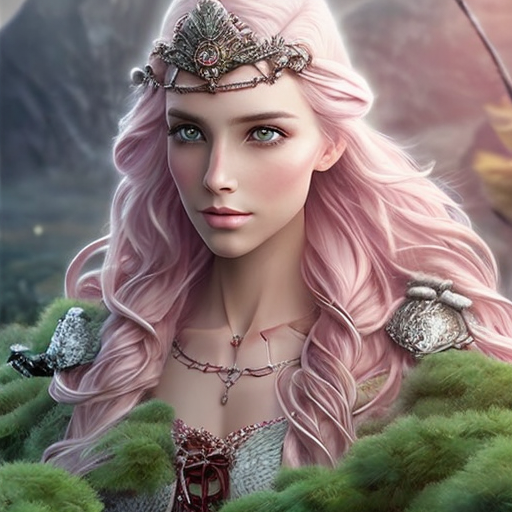

In [28]:
prompt = """blush,long hair,yellow eyes{{{{{{ond eyes}}}}}}large breasts{{dark skin}}side from,
wide view,two reg,cowboy shot,from above,full body,whole body,Please draw a picture in the genre tha
is best at, change seasons, wind autumn leaves,Beautiful  mountain{{{{{palette,Hair that gradually becomes one with the background}}}}}dynamic angle
"""

negative_prompt = "nsfw, yellow face, blue"

generate_image_with_neg(prompt, negative_prompt)

In [43]:
# pipe.safety_checker = lambda images, clip_input: (images, False)
pipe.safety_checker = None
pipe.requires_safety_checker = False

## Prompts

https://prompthero.com/search?model=Stable+Diffusion&q=yellow+eyes&source=8f3f1a04f6b&version=1.5

mdjrny-v4 style a colorful building, in the style of intricate cityscapes, cartoon mis-en-scene, photo-realistic landscapes, cinquecento, orientalism, 32k uhd, nostalgic illustration


  0%|          | 0/50 [00:00<?, ?it/s]

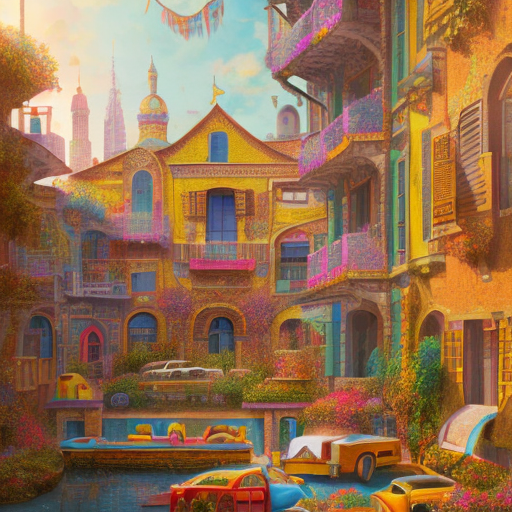

In [64]:
prompt = """a colorful building, in the style of intricate cityscapes, cartoon mis-en-scene, photo-realistic landscapes, cinquecento, orientalism, 32k uhd, nostalgic illustration"""

generate_image_with_neg(prompt)

## Oil painting

https://www.reddit.com/r/StableDiffusion/comments/y649yn/prompts_modifiers_to_get_midjourney_style_in/

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['water, canoes, refraction']


mdjrny-v4 style Professional oil painting of establishing shot of canal surrounded by verdant ((blue)) modern curved rustic Greek tiled buildings, professional majestic oil painting by Ed Blinkey, Atey Ghailan, Studio Ghibli, by ((Jeremy Mann)), Greg Manchess, Antonio Moro, (((trending on ArtStation))), trending on CGSociety, volumetric lighting, dramatic lighting, (dawn), water, canoes, refraction


  0%|          | 0/50 [00:00<?, ?it/s]

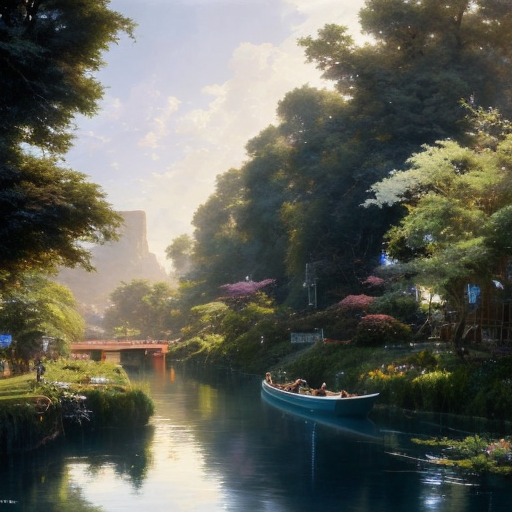

In [68]:
prompt = """Professional oil painting of establishing shot of canal surrounded by verdant ((blue)) modern curved rustic Greek tiled buildings, professional majestic oil painting by Ed Blinkey, Atey Ghailan, Studio Ghibli, by ((Jeremy Mann)), Greg Manchess, Antonio Moro, (((trending on ArtStation))), trending on CGSociety, volumetric lighting, dramatic lighting, (dawn), water, canoes, refraction"""

negative_prompt = """amateur, poorly drawn, ugly, flat"""

generate_image_with_neg(prompt, negative_prompt)